In [10]:
# Import libraries               # Same
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Reload the original dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Convert date column
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Convert skill strings into real Python lists
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

# Now filter to Data Engineeer jobs
df = df[df['job_title_short'] == 'Data Engineer']

In [2]:
# Convert posting date to month number (1-12)
df['job_posted_month_no'] = df['job_posted_date'].dt.month

# Keep only Data Engineer jobs
df = df[df['job_title_short'] == 'Data Engineer']

# Split the list of skills into separate rows
df_exploded = df.explode('job_skills')

# Create the pivot table
df_DA_pivot = df_exploded.pivot_table(
    index='job_posted_month_no',
    columns='job_skills',
    aggfunc='size',
    fill_value=0
)

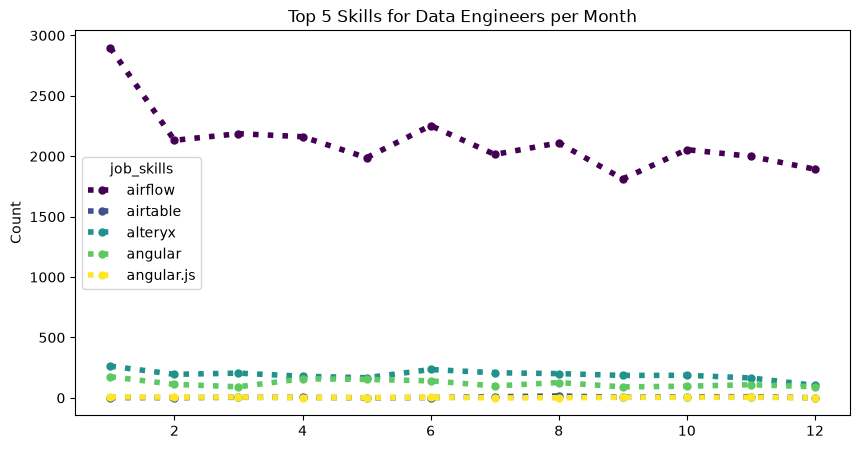

In [3]:
# Plot the top 5 skills over time
df_DA_pivot.iloc[:, :5].plot(
    kind='line',              # Create a line chart
    linewidth=4,              # Thickness of each line
    linestyle=':',            # Dotted line style (other options: '-', '--', '-.', ':')
    colormap='viridis',       # Color palette for the different lines
    marker='o',               # Circle marker at each data point
    markersize=5,             # Size of each marker
    figsize=(10, 5)           # Figure size: (width, height) in inches
)

# Add chart title and axis labels
plt.title('Top 5 Skills for Data Engineers per Month')   # Title displayed above the chart
plt.ylabel('Count')                                      # Y-axis = number of job postings
plt.xlabel('')                                           # Remove the x-axis label (month names are already shown)

# Display the finished chart
plt.show()

In [4]:
# Keep only Data Engineer job postings
# == compares two values (comparison operator)
# = assigns a value to a variable
df = df[df['job_title_short'] == 'Data Engineer']

# Split each list of skills into separate rows
df_exploded = df.explode('job_skills')          # One skill per row

# Calculate statistics for each skill
skill_stats = df_exploded.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),    # Median salary for each skill
    skill_count=('job_skills', 'count')             # Number of job postings mentioning each skill
)

# Number of top skills to display
skill_count = 20                                   # Show the top 20 most common skills

# Sort by frequency (largest → smallest) and keep only the top skills
skill_stats = skill_stats.sort_values(
    by='skill_count',                              # Sort using the skill_count column
    ascending=False                                # Descending order
).head(skill_count)                                # Keep only the first 20 rows

# Display the resulting DataFrame
skill_stats

,median_salary,skill_count
job_skills,,
sql,125000.0,113130
python,125000.0,108022
aws,130000.0,62049
azure,125000.0,60674
spark,134775.0,53656
java,134241.0,35559
kafka,140000.0,29073
hadoop,134241.0,28815
scala,137500.0,28716


In [5]:
import sys

print(sys.executable)

/usr/local/bin/python3.11


In [6]:
# Keep only Data Engineer job postings
df_DE = df[df['job_title_short'] == 'Data Engineer'].copy()

In [7]:
# Install adjustText into the SAME Python environment as this notebook kernel
%pip install adjustText


[notice] A new release of pip available: 22.3.1 -> 26.2
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
from adjustText import adjust_text

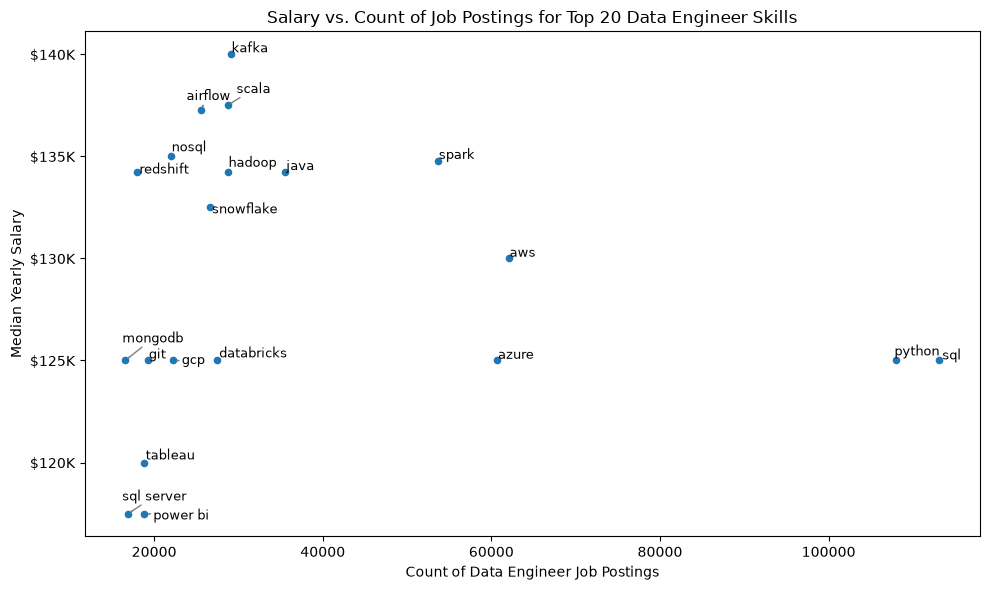

In [9]:
# Create the scatter plot
skill_stats.plot(
    kind='scatter',                 # One point per skill
    x='skill_count',                # X-axis = number of job postings
    y='median_salary',              # Y-axis = median salary
    figsize=(10, 6)                 # Make the chart larger for easier label spacing
)

# Store all text labels so adjust_text() can reposition them
texts = []

# Loop through each skill
for i, txt in enumerate(skill_stats.index):

    # Add the skill name at its scatter-plot coordinates
    texts.append(
        plt.text(
            skill_stats['skill_count'].iloc[i],       # X-coordinate
            skill_stats['median_salary'].iloc[i],     # Y-coordinate
            txt,                                      # Skill name
            fontsize=9                                # Slightly smaller labels
        )
    )

# Add chart labels/title BEFORE adjust_text()
plt.xlabel('Count of Data Engineer Job Postings')     # X-axis label
plt.ylabel('Median Yearly Salary')                    # Y-axis label
plt.title(
    f'Salary vs. Count of Job Postings for Top {skill_count} Data Engineer Skills'
)

# Format salary values: 140000 -> $140K
ax = plt.gca()                                        # Get the current chart
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, pos: f'${int(y / 1000)}K')
)

# Clean up figure spacing first
plt.tight_layout()

# Move overlapping skill labels apart
# Call this AFTER the rest of the plot formatting
adjust_text(
    texts,
    ax=ax,                                            # Adjust labels on this chart
    arrowprops=dict(
        arrowstyle='->',                              # Arrow points back to original dot
        color='gray'
    )
)

# Display the finished chart
plt.show()